# Importing Libraries


In [21]:
import cv2
import mediapipe as mp

import matplotlib.pyplot as plt
import numpy as np

import random
import os
from tqdm.notebook import tqdm

from glob import glob
import IPython.display as ipd

# Extracting Required Paths


In [22]:
input_path = [i for i in glob('Dataset\*\*\*.mp4')]
# First removing the path by split and then splitting the string to get the label
output_label = [(i.split("\\")[-1]).split(" ")[1:][0] for i in glob('Dataset\*\*')] 

print(len(output_label))
# for i in output_label:
#     if i not in glob('MP_Data\*\*'):
#         output_label.remove(i)

print(len(output_label))
input_path

8
8


['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9536.mp4',
 'Dataset\\Ad

# Loading Video in OpenCV

In [4]:
random_video = random.choice(input_path)
print(random_video)

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

Dataset\Adjectives\1. loud\MVI_5335.mp4
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


# Prepering Mediapipe

In [5]:
mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 

In [6]:
def mediapipe_detection(image, model) -> tuple:
    image_ = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image_.flags.writeable = False                  
    results = model.process(image_) 
    image_.flags.writeable = True                   
    image = cv2.cvtColor(image_, cv2.COLOR_RGB2BGR) 
    return image, results

In [7]:
def draw_landmarks(image, results) -> None:
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [8]:
def draw_styled_landmarks(image, results) -> None:
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [19]:
def extract_keypoints(results) -> np.array:
    
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    # face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    # lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    # rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    
    # return np.concatenate([pose, lh, rh])
    return pose

# Collecting MP data


## INCLUDE 50


In [17]:
#Creating dir for each label
try:
    # os.mkdir('MP_data')
    for i in range(len(output_label)):
        os.mkdir(f'MP_data/{output_label[i]}')
except:
    print("Directory already exists")

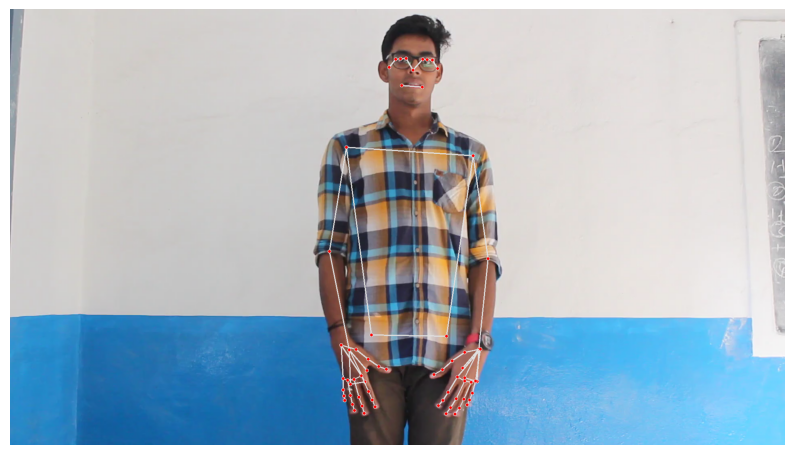

In [11]:
def display_cv2_image(img, figsize = (10,10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig,ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis('off')
    
ret, frame = cap.read()

img,res = mediapipe_detection(frame, mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5))

cap.release()

draw_landmarks(img, res)

display_cv2_image(img)



In [23]:
holistic = mp_holistic.Holistic(min_detection_confidence=0.7, min_tracking_confidence=0.7)
DATA_PATH = "MP_data\\"

In [ ]:


# Applying an algo to filter 50 labels and there addresses
input_path = glob('Dataset\*\*\*.mp4')
include_50 = [i.split("\\")[-1] for i in glob('MP_Data\*')]    

print(input_path)

input_label = list(set([" ".join((i.split("\\")[-2]).split(" ")[1:]) for i in input_path]))

print(input_label)

labels = []
for i in input_label:
    if i in include_50:
        labels.append(i)

paths = []
for i in input_path:
     if (" ".join((i.split("\\")[-2]).split(" ")[1:])) in include_50:
        paths.append(i)

print(len(labels),len(paths))

['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9536.mp4', 'Dataset\\Adjectives\\2. quiet\\M

In [24]:
# Loop through sequences aka videos

for ip in tqdm(input_path):
# for ip in tqdm(paths): # Looping through selected 50 labels
    cap = cv2.VideoCapture(ip)
    all_keypoints = []
    keypoints = np.array(None)
        
       
    while cap.isOpened():           
        # Read feed
        ret, frame = cap.read()
        if not ret:
            break
        
        # Make detections
        image, results = mediapipe_detection(frame, holistic)
            
        #Collecting 3D landmarks for a single frame
        keypoints = extract_keypoints(results)
        all_keypoints.append(keypoints)        

    all_keypoints = np.vstack(all_keypoints)

    # all_avg_keypoints = [[0] * 258] * len(all_keypoints)
    # all_avg_keypoints[0] = all_keypoints[0]
    # all_avg_keypoints[1] = all_keypoints[1]


    # # Finding average of all past 3 keypoint values
    # for keypoint in range(2,len(all_keypoints)):
    #     counter = 0
        
    #     for cordinate_1,cordinate_2,cordinate_3 in zip(all_keypoints[keypoint],all_keypoints[keypoint-1],all_keypoints[keypoint-2]):
    #         avg = (cordinate_1+cordinate_2+cordinate_3)/3

    #         all_avg_keypoints[keypoint][counter] = avg
    #         counter += 1
        
    # Saving Landmarks
    path = ip.split("/")
    
    # Getting Current action of the video
    action = " ".join((ip.split("\\")[-2]).split(" ")[1:])
    
    #Get the sequence number
    sequence = ip.split("\\")[-1][:-4]
    
    npy_path = os.path.join(DATA_PATH, action, sequence)
    print(npy_path)
    
    np.save(npy_path, all_keypoints)

    cap.release()

  0%|          | 0/103 [00:00<?, ?it/s]

MP_data\loud\MVI_5177
MP_data\loud\MVI_5178
MP_data\loud\MVI_5179
MP_data\loud\MVI_5257
MP_data\loud\MVI_5258
MP_data\loud\MVI_5259
MP_data\loud\MVI_5335
MP_data\loud\MVI_5336
MP_data\loud\MVI_5337
MP_data\loud\MVI_9289
MP_data\loud\MVI_9290
MP_data\loud\MVI_9291
MP_data\loud\MVI_9368
MP_data\loud\MVI_9369
MP_data\loud\MVI_9370
MP_data\loud\MVI_9448
MP_data\loud\MVI_9449
MP_data\loud\MVI_9450
MP_data\loud\MVI_9534
MP_data\loud\MVI_9535
MP_data\loud\MVI_9536
MP_data\quiet\MVI_5180
MP_data\quiet\MVI_5181
MP_data\quiet\MVI_5182
MP_data\quiet\MVI_5260
MP_data\quiet\MVI_5261
MP_data\quiet\MVI_5262
MP_data\quiet\MVI_5338
MP_data\quiet\MVI_5339
MP_data\quiet\MVI_5340
MP_data\quiet\MVI_9292
MP_data\quiet\MVI_9293
MP_data\quiet\MVI_9294
MP_data\quiet\MVI_9371
MP_data\quiet\MVI_9372
MP_data\quiet\MVI_9373
MP_data\quiet\MVI_9451
MP_data\quiet\MVI_9452
MP_data\quiet\MVI_9453
MP_data\quiet\MVI_9537
MP_data\quiet\MVI_9538
MP_data\quiet\MVI_9539
MP_data\happy\MVI_5183
MP_data\happy\MVI_5184
MP_data\h